<a href="https://colab.research.google.com/github/WVF-1/Introduction-to-Audio-Data/blob/main/NB2_Feature_Extraction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🎧 Audio Data Month — Project 1, Notebook 2
## Feature Extraction & Pattern Discovery: How Machines Hear

> **Newsletter context:** In Notebook 1 we learned to *see* sound — waveforms, spectra, spectrograms. But a raw spectrogram is a large image, not a number a model can work with. This notebook answers the next question: how do we compress that rich visual information into a compact set of numbers that still captures the essence of a sound?

The answer is **MFCCs** — Mel-Frequency Cepstral Coefficients — and they are the bridge between audio perception and machine learning.

**What you will build by the end of this notebook:**
1. An MFCC extraction pipeline across all of fold1
2. A feature matrix: one row per clip, one column per feature
3. A class-level MFCC heatmap — the fingerprint of each sound category
4. A PCA projection showing whether classes cluster in feature space
5. A t-SNE map giving the clearest possible visual separation
6. A simple random forest classifier as a baseline — the reader challenge

**Libraries:** `librosa`, `numpy`, `pandas`, `matplotlib`, `seaborn`, `scikit-learn`

← Back to [Notebook 1: Sensory Foundations](NB1_Sensory_Foundations.ipynb)

---

## 0 · Setup

In [6]:
# !pip install librosa --quiet

In [7]:
import os
import glob
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import librosa
import librosa.display
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

# ── Palette (consistent with Notebook 1) ─────────────────────────────────────
BG    = '#1a1a2e'
PANEL = '#16213e'
AMBER = '#e8a838'
TEAL  = '#2ec4b6'
CORAL = '#e76f51'
MUTED = '#8d99ae'
WHITE = '#edf2f4'

# 10 distinct colours — one per class, ordered by class_id
CLASS_COLOURS = [
    '#4cc9f0', '#f72585', '#7209b7', '#e8a838', '#2ec4b6',
    '#e76f51', '#06d6a0', '#ffd166', '#8d99ae', '#ef233c'
]

plt.rcParams.update({
    'figure.facecolor': BG,
    'axes.facecolor':   PANEL,
    'axes.edgecolor':   MUTED,
    'axes.labelcolor':  WHITE,
    'xtick.color':      MUTED,
    'ytick.color':      MUTED,
    'text.color':       WHITE,
    'grid.color':       '#2a2a4a',
    'grid.linestyle':   '--',
    'grid.alpha':       0.5,
    'font.family':      'DejaVu Sans',
    'font.size':        11,
    'axes.titlesize':   13,
    'axes.titleweight': 'bold',
    'figure.dpi':       120,
})

print('Setup complete.')

Setup complete.


In [8]:
# ── Path configuration ────────────────────────────────────────────────────────
# Files are uploaded flat to /content/ in Colab.
# Format: [fsID]-[classID]-[occurrenceID]-[sliceID].wav

FOLD1_DIR = '/content/'   # ← adjust if running locally

CLASS_MAP = {
    0: 'air_conditioner',
    1: 'car_horn',
    2: 'children_playing',
    3: 'dog_bark',
    4: 'drilling',
    5: 'engine_idling',
    6: 'gun_shot',
    7: 'jackhammer',
    8: 'siren',
    9: 'street_music',
}

def class_from_filename(path):
    name = os.path.basename(path)
    class_id = int(name.split('-')[1])
    return class_id, CLASS_MAP[class_id]

all_files = sorted(glob.glob(os.path.join(FOLD1_DIR, '*.wav')))
print(f'Found {len(all_files)} files in fold1.')

rows = []
for f in all_files:
    cid, cname = class_from_filename(f)
    rows.append({'path': f, 'class_id': cid, 'class_name': cname})
meta = pd.DataFrame(rows)

print('\nClass distribution in fold1:')
print(meta['class_name'].value_counts().to_string())

Found 46 files in fold1.

Class distribution in fold1:
class_name
dog_bark            19
gun_shot            15
street_music         7
children_playing     4
drilling             1


---
## 1 · What are MFCCs?

In Notebook 1, we built a mel-spectrogram: a 2D image where the frequency axis is warped to match human perception. That image might be 128 frequency bins × 173 time frames = **22,144 numbers** per clip. That is too large and too redundant to hand directly to a model.

**MFCCs** compress this further by applying a second transformation — the **Discrete Cosine Transform** — to the mel-spectrogram. This is the same mathematical trick used in JPEG compression. It separates the *slow-varying shape* of the spectrum (which captures timbre) from the *fast-varying fine structure* (which carries less perceptual information).

We keep only the first **13 coefficients**. Each coefficient captures a different aspect of the spectral envelope:
- **MFCC 1** ≈ overall energy / loudness
- **MFCCs 2–4** ≈ broad spectral shape (is it bright or dark?)
- **MFCCs 5–13** ≈ progressively finer timbral texture

For each clip, we summarise each MFCC track with its **mean** and **standard deviation** over time. That gives us 13 × 2 = **26 features per clip** — a dramatic compression from 22,144 numbers, but one that retains the characteristics a listener would use to distinguish a dog bark from a jackhammer.

---
## 2 · MFCC Visualisation — A Single Clip

Before we extract features in bulk, let us look at what the MFCC representation actually looks like for two contrasting clips.

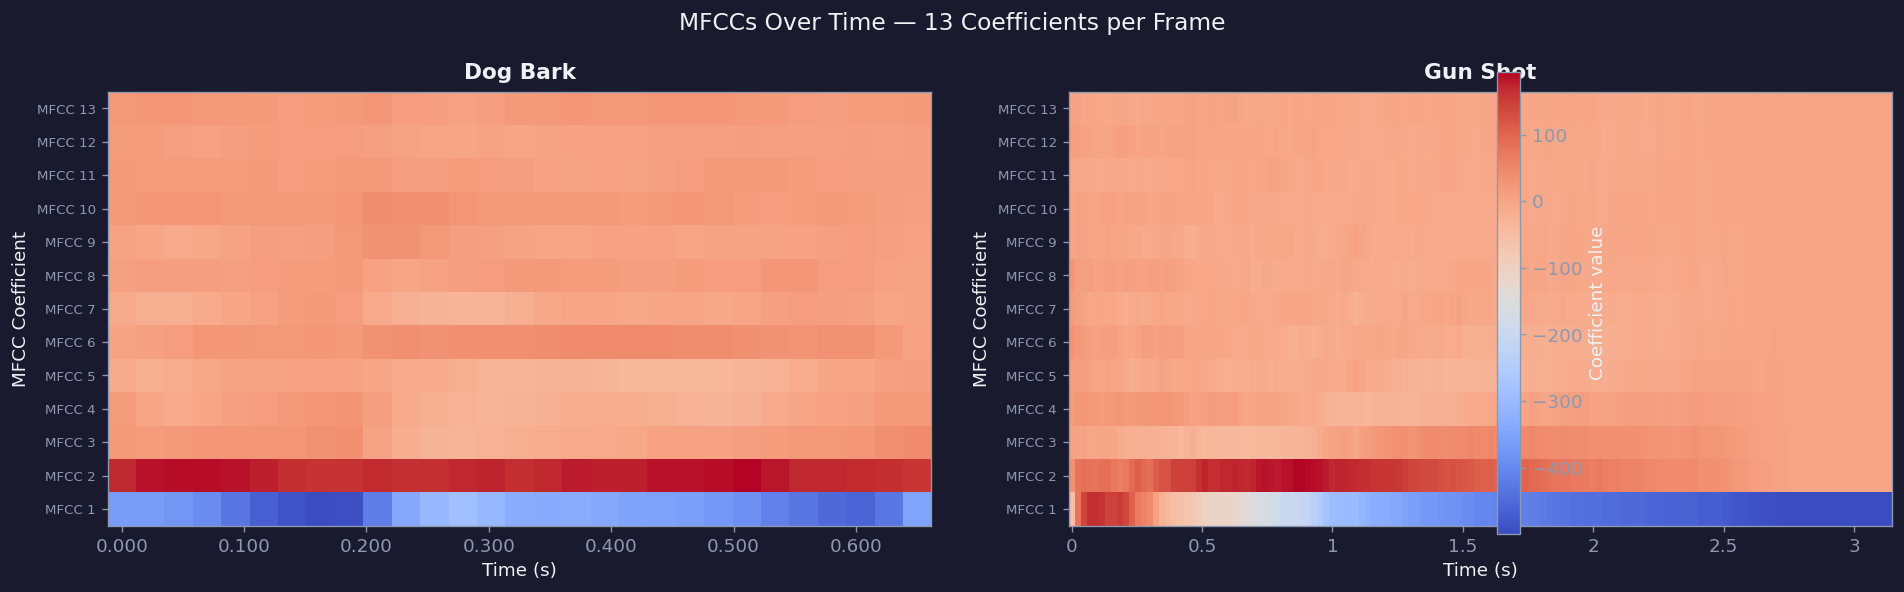

Each row is one MFCC. Colour shows how that coefficient varies across the clip.
The gun shot and dog bark both show abrupt changes — bursts of energy separated by silence.


In [9]:
SR = 22050   # standard resampling rate used throughout

dog_path    = meta[meta['class_name'] == 'dog_bark']['path'].iloc[0]
gun_shot_path  = meta[meta['class_name'] == 'gun_shot']['path'].iloc[0]

y_dog,   _ = librosa.load(dog_path,   sr=SR, mono=True)
y_gun_shot, _ = librosa.load(gun_shot_path, sr=SR, mono=True)

mfcc_dog   = librosa.feature.mfcc(y=y_dog,   sr=SR, n_mfcc=13)
mfcc_gun_shot = librosa.feature.mfcc(y=y_gun_shot, sr=SR, n_mfcc=13)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('MFCCs Over Time — 13 Coefficients per Frame', fontsize=14)

for ax, mfcc, label in [
    (axes[0], mfcc_dog,   'Dog Bark'),
    (axes[1], mfcc_gun_shot, 'Gun Shot'),
]:
    img = librosa.display.specshow(
        mfcc, sr=SR, hop_length=512,
        x_axis='time', ax=ax,
        cmap='coolwarm'
    )
    ax.set_title(label, pad=8)
    ax.set_ylabel('MFCC Coefficient', color=WHITE)
    ax.set_xlabel('Time (s)', color=WHITE)
    ax.set_yticks(range(13))
    ax.set_yticklabels([f'MFCC {i+1}' for i in range(13)], fontsize=8)
    ax.set_facecolor(PANEL)

fig.colorbar(img, ax=axes, label='Coefficient value', pad=0.01)
plt.tight_layout()
plt.savefig('nb2_fig1_mfcc_tracks.png', bbox_inches='tight', facecolor=BG)
plt.show()
print('Each row is one MFCC. Colour shows how that coefficient varies across the clip.')
print('The gun shot and dog bark both show abrupt changes — bursts of energy separated by silence.')

---
## 3 · Building the Feature Matrix

Now we extract features from every clip in fold1. For each file we compute:
- 13 MFCC means (the average value of each coefficient over time)
- 13 MFCC standard deviations (how much each coefficient varies)

The result is a matrix with one row per clip and 26 columns — ready for any downstream analysis or model.

In [10]:
N_MFCC = 13

def extract_features(path, sr=SR, n_mfcc=N_MFCC):
    """Load a clip and return a flat vector of MFCC mean + std."""
    y, _ = librosa.load(path, sr=sr, mono=True)
    mfcc  = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)
    means = mfcc.mean(axis=1)   # shape: (n_mfcc,)
    stds  = mfcc.std(axis=1)    # shape: (n_mfcc,)
    return np.concatenate([means, stds])

# Column names for the feature DataFrame
feat_cols = (
    [f'mfcc_{i+1}_mean' for i in range(N_MFCC)] +
    [f'mfcc_{i+1}_std'  for i in range(N_MFCC)]
)

print(f'Extracting features from {len(meta)} clips...')
t0 = time.time()

feat_rows = []
for i, row in meta.iterrows():
    feats = extract_features(row['path'])
    feat_rows.append(feats)
    if (i + 1) % 100 == 0:
        elapsed = time.time() - t0
        print(f'  {i+1}/{len(meta)} clips processed ({elapsed:.0f}s elapsed)')

X = pd.DataFrame(feat_rows, columns=feat_cols)
X['class_id']   = meta['class_id'].values
X['class_name'] = meta['class_name'].values

print(f'\nDone in {time.time() - t0:.1f}s.')
print(f'Feature matrix shape: {X.shape}  ({X.shape[0]} clips × {X.shape[1]-2} features)')
print('\nSample rows:')
X.head(3)

Extracting features from 46 clips...

Done in 1.1s.
Feature matrix shape: (46, 28)  (46 clips × 26 features)

Sample rows:


,mfcc_1_mean,mfcc_2_mean,mfcc_3_mean,mfcc_4_mean,mfcc_5_mean,mfcc_6_mean,mfcc_7_mean,mfcc_8_mean,mfcc_9_mean,mfcc_10_mean,...,mfcc_6_std,mfcc_7_std,mfcc_8_std,mfcc_9_std,mfcc_10_std,mfcc_11_std,mfcc_12_std,mfcc_13_std,class_id,class_name
0,-348.950989,40.240105,-29.645321,32.042835,-4.321028,-1.781995,6.216391,-0.595090,-5.571595,16.741766,...,4.665419,6.524759,5.352282,6.767574,5.360464,3.748676,4.495212,4.705792,4,drilling
1,-304.740295,80.139168,-38.740913,10.429260,-15.710652,-1.264518,-14.098667,-6.586172,-11.681387,-5.606474,...,5.884735,8.028746,9.014706,5.062147,6.591641,5.253163,6.563783,5.208781,2,children_playing
2,-460.304474,166.987717,1.929655,24.718557,12.992788,8.409292,8.187362,11.318299,0.625030,7.410621,...,5.138559,5.415921,5.205445,5.472347,4.876910,4.770077,3.796042,4.658859,9,street_music


---
## 4 · Class-Level MFCC Fingerprints

Each sound class has a characteristic MFCC profile. The heatmap below shows the **mean value of each MFCC** aggregated across all clips of each class. Think of each row as the timbral fingerprint of that sound category.

Classes that look similar in this heatmap will be harder to distinguish. Classes with very different colour patterns are easily separable.

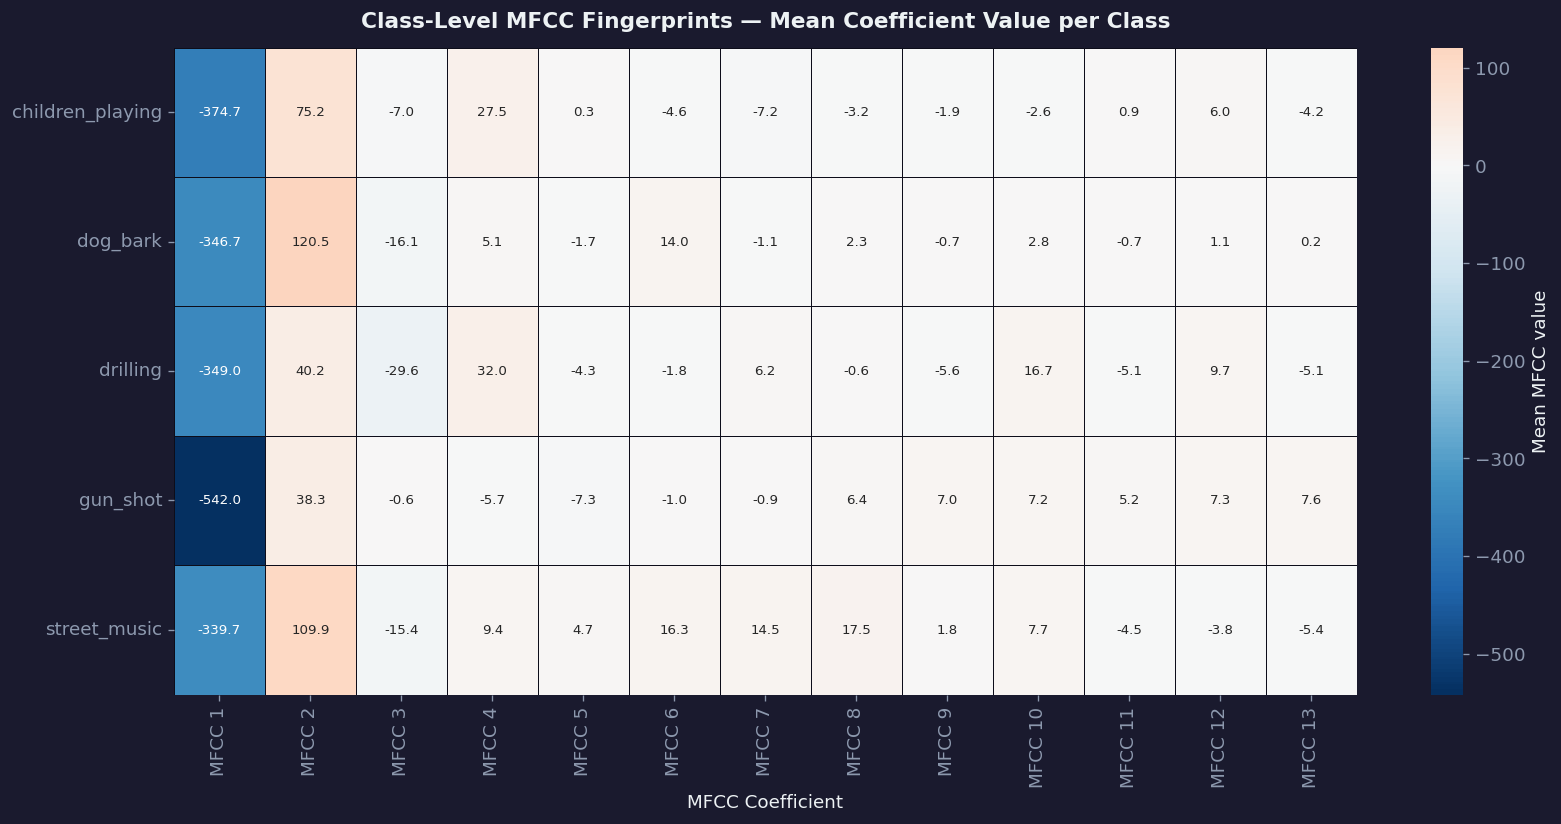

Reading the heatmap:
  Blue  → negative coefficient value (smooth / quiet spectral region)
  Red   → positive coefficient value (energetic spectral region)
  MFCC 1 captures overall energy; higher MFCCs capture finer timbral texture.
  Gun shot and car horn stand out clearly — impulsive sounds have distinctive profiles.


In [11]:
# Average the 13 MFCC means per class
mean_cols = [f'mfcc_{i+1}_mean' for i in range(N_MFCC)]
class_profiles = X.groupby('class_name')[mean_cols].mean()
class_profiles.columns = [f'MFCC {i+1}' for i in range(N_MFCC)]

fig, ax = plt.subplots(figsize=(14, 7))
sns.heatmap(
    class_profiles,
    ax=ax,
    cmap='RdBu_r',
    center=0,
    annot=True,
    fmt='.1f',
    linewidths=0.4,
    linecolor='#0d0d1a',
    annot_kws={'size': 8},
    cbar_kws={'label': 'Mean MFCC value'}
)
ax.set_title('Class-Level MFCC Fingerprints — Mean Coefficient Value per Class', pad=12)
ax.set_xlabel('MFCC Coefficient')
ax.set_ylabel('')
ax.tick_params(axis='y', rotation=0)
plt.tight_layout()
plt.savefig('nb2_fig2_mfcc_heatmap.png', bbox_inches='tight', facecolor=BG)
plt.show()
print('Reading the heatmap:')
print('  Blue  → negative coefficient value (smooth / quiet spectral region)')
print('  Red   → positive coefficient value (energetic spectral region)')
print('  MFCC 1 captures overall energy; higher MFCCs capture finer timbral texture.')
print('  Gun shot and car horn stand out clearly — impulsive sounds have distinctive profiles.')

---
## 5 · MFCC Distributions by Class

The heatmap shows averages. But averages hide spread. Here we look at the full distribution of the two most informative MFCCs — MFCC 1 (overall energy) and MFCC 2 (broadest spectral shape) — as violin plots, one per class.

Wide, well-separated violins → the model has an easy job. Narrow, overlapping violins → the model needs to work harder.

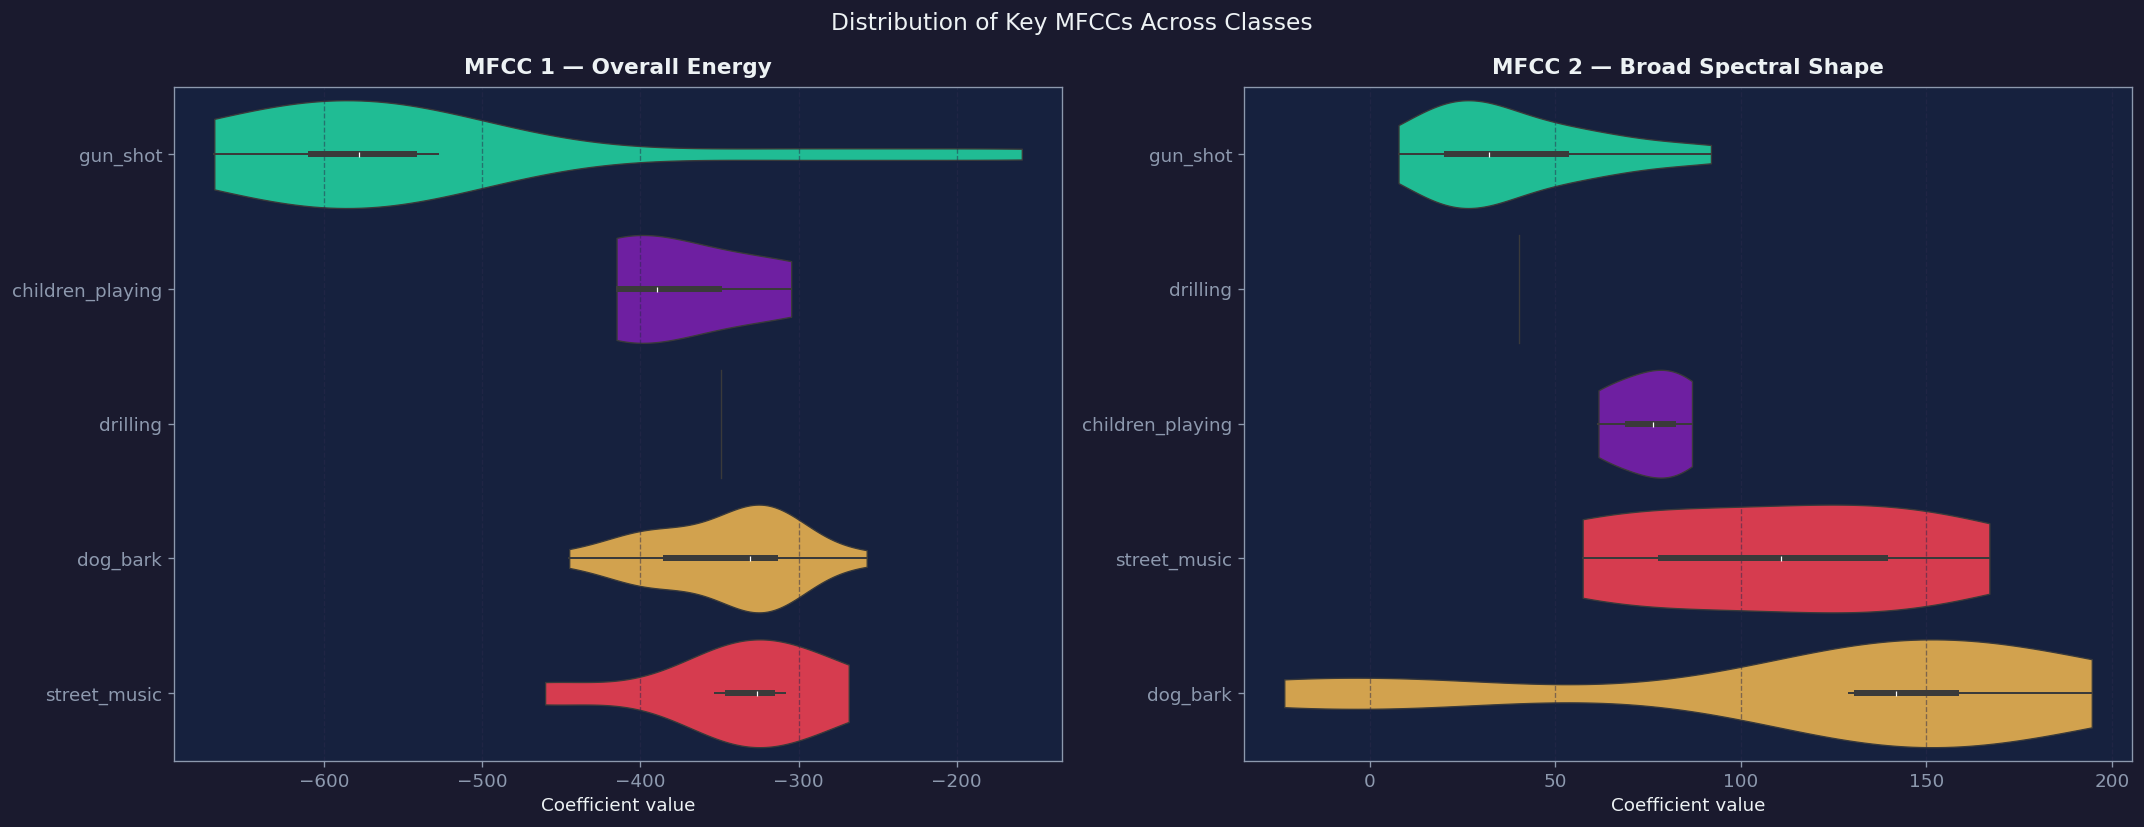

Classes with narrow, well-separated distributions are easiest for a model to classify.
Gun shot and car horn (impulsive, brief) tend to be distinct.
Drilling and jackhammer (similar broadband texture) tend to overlap.


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Distribution of Key MFCCs Across Classes', fontsize=14)

for ax, col, title in [
    (axes[0], 'mfcc_1_mean', 'MFCC 1 — Overall Energy'),
    (axes[1], 'mfcc_2_mean', 'MFCC 2 — Broad Spectral Shape'),
]:
    order = X.groupby('class_name')[col].median().sort_values().index
    palette = {cname: CLASS_COLOURS[CLASS_MAP_INV[cname]]
               for cname in order
               if cname in {v: k for k, v in __builtins__.__dict__.items() if False}}
    # Build palette from CLASS_MAP
    inv_map = {v: k for k, v in CLASS_MAP.items()}
    pal = {cname: CLASS_COLOURS[inv_map[cname]] for cname in order}

    sns.violinplot(
        data=X,
        x=col,
        y='class_name',
        order=order,
        palette=pal,
        ax=ax,
        inner='box',
        linewidth=0.8,
        cut=0
    )
    ax.set_title(title, pad=8)
    ax.set_xlabel('Coefficient value')
    ax.set_ylabel('')
    ax.grid(True, axis='x')
    ax.set_facecolor(PANEL)

plt.tight_layout()
plt.savefig('nb2_fig3_violins.png', bbox_inches='tight', facecolor=BG)
plt.show()
print('Classes with narrow, well-separated distributions are easiest for a model to classify.')
print('Gun shot and car horn (impulsive, brief) tend to be distinct.')
print('Drilling and jackhammer (similar broadband texture) tend to overlap.')

---
## 6 · PCA — Finding the Axes of Variation

We have 26 features per clip. **Principal Component Analysis (PCA)** finds the directions in that 26-dimensional space along which the data varies most, and projects everything down to 2 dimensions so we can plot it.

PCA is linear — it finds straight-line directions. If classes separate cleanly in a PCA plot, they are linearly separable in feature space and easy to classify. If they overlap, the signal is there but it is curved or tangled — which is where t-SNE (next section) can help.

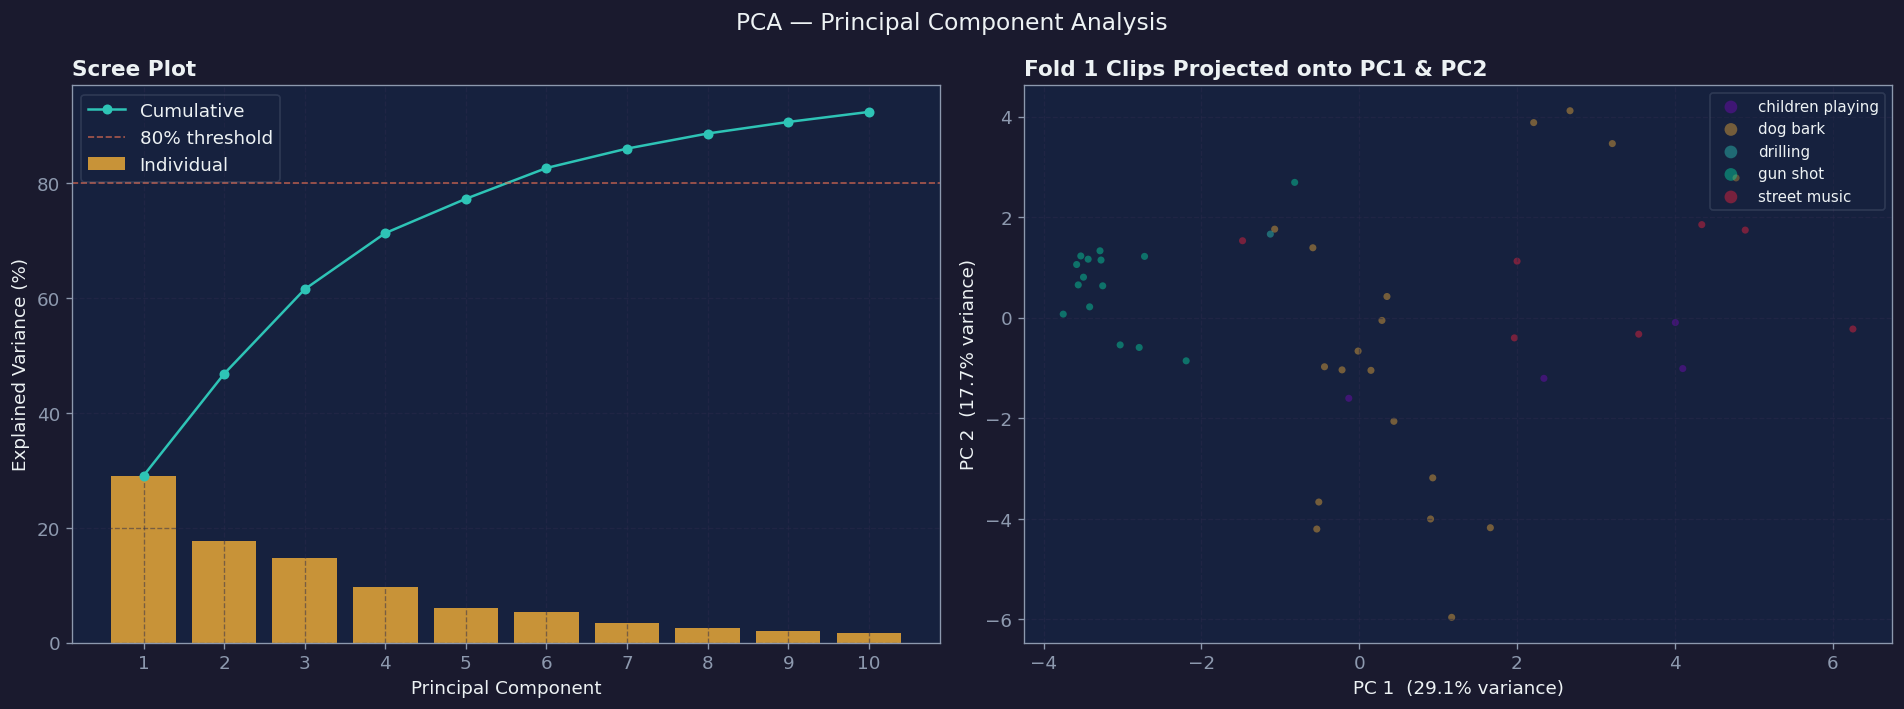

The first 2 PCs capture 46.8% of total variance.
Some classes cluster loosely, but there is substantial overlap.
PCA is linear — it cannot capture curved or non-linear structure.
That is where t-SNE helps.


In [13]:
# Isolate features, scale to zero mean / unit variance before PCA
feature_cols = [c for c in X.columns if c.startswith('mfcc')]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X[feature_cols])

pca = PCA(n_components=10, random_state=42)
X_pca = pca.fit_transform(X_scaled)

# ── Explained variance scree plot ──
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('PCA — Principal Component Analysis', fontsize=14)

# Scree plot
ev = pca.explained_variance_ratio_ * 100
cumev = np.cumsum(ev)
ax = axes[0]
ax.bar(range(1, 11), ev, color=AMBER, alpha=0.85, label='Individual')
ax.plot(range(1, 11), cumev, color=TEAL, marker='o', linewidth=1.5, markersize=5, label='Cumulative')
ax.axhline(80, color=CORAL, linestyle='--', linewidth=1.0, alpha=0.7, label='80% threshold')
ax.set_xlabel('Principal Component')
ax.set_ylabel('Explained Variance (%)')
ax.set_title('Scree Plot', loc='left')
ax.set_xticks(range(1, 11))
ax.legend(framealpha=0.2, edgecolor=MUTED)
ax.grid(True)
ax.set_facecolor(PANEL)

# 2D scatter (PC1 vs PC2)
inv_map = {v: k for k, v in CLASS_MAP.items()}
ax = axes[1]
for cname in sorted(X['class_name'].unique()):
    mask = X['class_name'] == cname
    cid  = inv_map[cname]
    ax.scatter(
        X_pca[mask, 0], X_pca[mask, 1],
        color=CLASS_COLOURS[cid], alpha=0.45, s=18,
        label=cname.replace('_', ' '), edgecolors='none'
    )
ax.set_xlabel(f'PC 1  ({ev[0]:.1f}% variance)')
ax.set_ylabel(f'PC 2  ({ev[1]:.1f}% variance)')
ax.set_title('Fold 1 Clips Projected onto PC1 & PC2', loc='left')
ax.legend(
    framealpha=0.2, edgecolor=MUTED,
    markerscale=1.8, fontsize=9,
    loc='upper right'
)
ax.grid(True)
ax.set_facecolor(PANEL)

plt.tight_layout()
plt.savefig('nb2_fig4_pca.png', bbox_inches='tight', facecolor=BG)
plt.show()
print(f'The first 2 PCs capture {cumev[1]:.1f}% of total variance.')
print('Some classes cluster loosely, but there is substantial overlap.')
print('PCA is linear — it cannot capture curved or non-linear structure.')
print('That is where t-SNE helps.')

---
## 7 · t-SNE — Unfolding the Non-Linear Structure

**t-SNE** (t-Distributed Stochastic Neighbour Embedding) is a non-linear dimensionality reduction technique. Unlike PCA, it does not try to find straight-line axes — instead it tries to preserve *local neighbourhood structure*: clips that are similar in feature space end up close together in the 2D map.

A well-formed t-SNE plot for a classification problem shows tight, well-separated clusters — one per class. Where clusters overlap, those are the hard cases for any model.

> **Note:** t-SNE distances between clusters are not meaningful — only the within-cluster tightness and between-cluster separation matter.

Running t-SNE — this takes ~30–60 seconds...
Done in 0s.


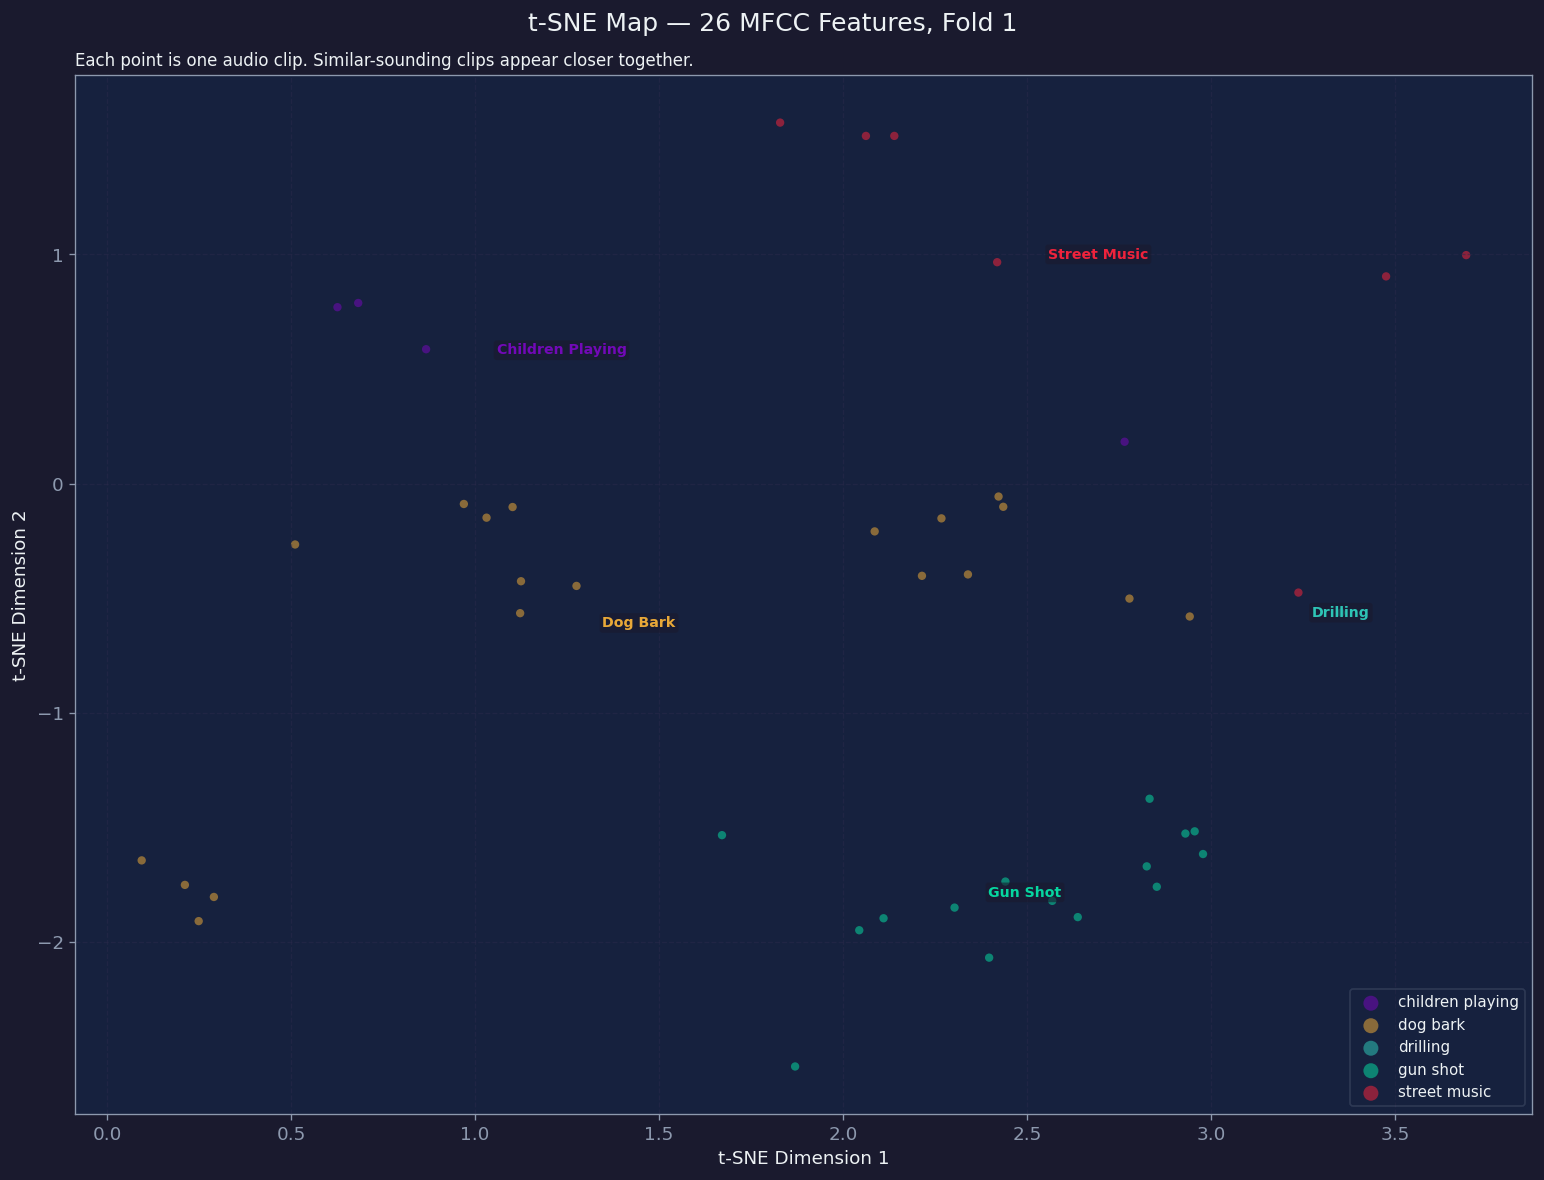

Tight, isolated clusters → easy to classify (gun_shot, car_horn).
Overlapping, diffuse clusters → harder to distinguish (drilling vs jackhammer).


In [14]:
# Run t-SNE on the scaled features (perplexity=30 is a reasonable default for ~800 clips)
print('Running t-SNE — this takes ~30–60 seconds...')
t0 = time.time()
tsne = TSNE(n_components=2, perplexity=30, learning_rate='auto',
            init='pca', random_state=42, n_iter=1000)
X_tsne = tsne.fit_transform(X_scaled)
print(f'Done in {time.time() - t0:.0f}s.')

fig, ax = plt.subplots(figsize=(13, 10))
fig.suptitle('t-SNE Map — 26 MFCC Features, Fold 1', fontsize=15)

for cname in sorted(X['class_name'].unique()):
    mask = (X['class_name'] == cname).values
    cid  = inv_map[cname]
    ax.scatter(
        X_tsne[mask, 0], X_tsne[mask, 1],
        color=CLASS_COLOURS[cid],
        alpha=0.55, s=25, edgecolors='none',
        label=cname.replace('_', ' ')
    )

# Annotate cluster centroids for readability
for cname in X['class_name'].unique():
    mask  = (X['class_name'] == cname).values
    cx    = X_tsne[mask, 0].mean()
    cy    = X_tsne[mask, 1].mean()
    cid   = inv_map[cname]
    label = cname.replace('_', ' ').title()
    ax.text(cx, cy, label,
            fontsize=8.5, fontweight='bold',
            color=CLASS_COLOURS[cid],
            ha='center', va='center',
            bbox=dict(boxstyle='round,pad=0.2', facecolor=BG, alpha=0.6, edgecolor='none'))

ax.set_xlabel('t-SNE Dimension 1')
ax.set_ylabel('t-SNE Dimension 2')
ax.set_title('Each point is one audio clip. Similar-sounding clips appear closer together.',
             loc='left', fontsize=10, fontweight='normal')
ax.grid(True)
ax.set_facecolor(PANEL)
ax.legend(framealpha=0.2, edgecolor=MUTED, markerscale=1.8, fontsize=9,
          loc='lower right')

plt.tight_layout()
plt.savefig('nb2_fig5_tsne.png', bbox_inches='tight', facecolor=BG)
plt.show()
print('Tight, isolated clusters → easy to classify (gun_shot, car_horn).')
print('Overlapping, diffuse clusters → harder to distinguish (drilling vs jackhammer).')

---
## 8 · Baseline Classifier — Can We Predict the Sound?

We now have a 26-feature matrix and 10 class labels. Let us fit a **Random Forest** and evaluate it with 5-fold cross-validation. This is not a serious modelling effort — it is a *sanity check*: if MFCC features carry real discriminative information, accuracy should be well above the chance baseline of 10%.

The confusion matrix will also tell us exactly which classes are being confused — validating what we saw in the t-SNE map.

In [15]:
labels = X['class_name'].values

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(rf, X_scaled, labels, cv=cv, scoring='accuracy')

print('5-Fold Cross-Validation Accuracy (Random Forest, 26 MFCC features):')
print(f'  Per-fold:  {[round(s,3) for s in scores]}')
print(f'  Mean:      {scores.mean():.3f}')
print(f'  Std:       {scores.std():.3f}')
print(f'  Chance baseline: 0.100  (10 classes, uniform distribution)')
print(f'  Lift over chance: {scores.mean() / 0.1:.1f}x')

5-Fold Cross-Validation Accuracy (Random Forest, 26 MFCC features):
  Per-fold:  [np.float64(0.9), np.float64(0.889), np.float64(0.667), np.float64(0.889), np.float64(1.0)]
  Mean:      0.869
  Std:       0.109
  Chance baseline: 0.100  (10 classes, uniform distribution)
  Lift over chance: 8.7x


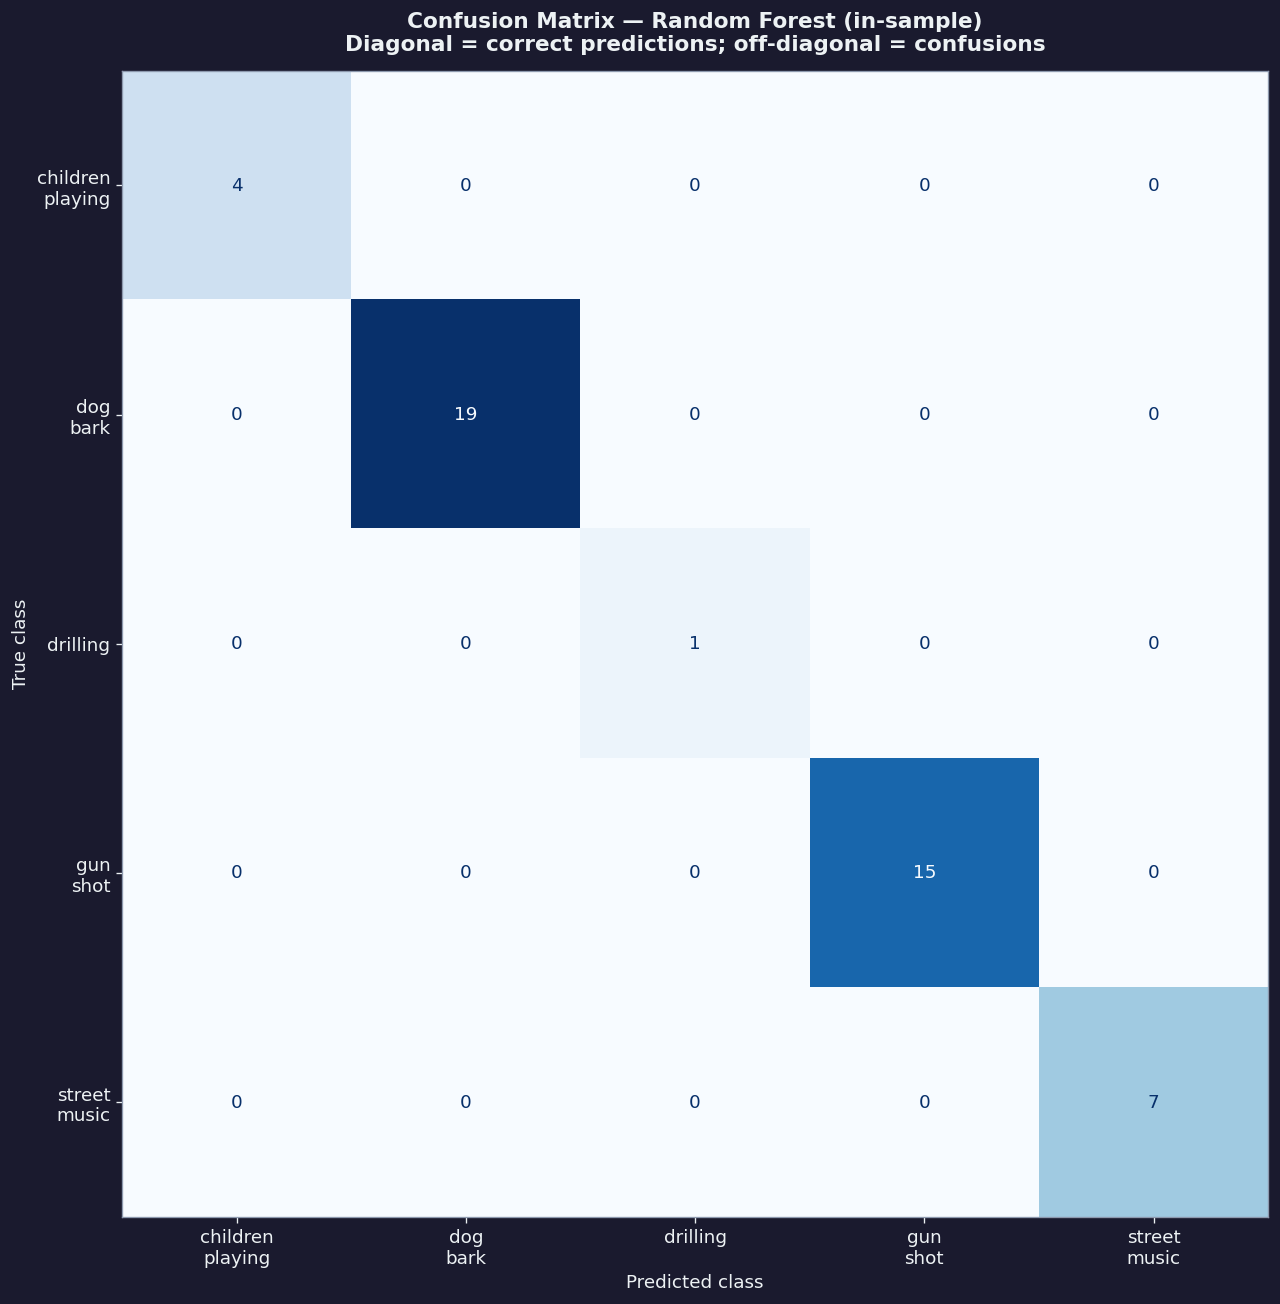

Compare the off-diagonal confusions with the overlapping clusters in the t-SNE map.
They should match: the model struggles exactly where the clusters overlapped.


In [16]:
# Fit on the full fold1 set and produce a confusion matrix for interpretation
rf.fit(X_scaled, labels)
preds = rf.predict(X_scaled)   # in-sample, for the confusion matrix illustration

class_order = sorted(X['class_name'].unique())
disp_labels = [c.replace('_', '\n') for c in class_order]

fig, ax = plt.subplots(figsize=(13, 11))
cmd = ConfusionMatrixDisplay.from_predictions(
    labels, preds,
    labels=class_order,
    display_labels=disp_labels,
    ax=ax,
    cmap='Blues',
    colorbar=False,
    xticks_rotation=0
)
ax.set_title(
    'Confusion Matrix — Random Forest (in-sample)\n'
    'Diagonal = correct predictions; off-diagonal = confusions',
    pad=12
)
ax.set_xlabel('Predicted class')
ax.set_ylabel('True class')
ax.tick_params(axis='both', colors=WHITE)
ax.set_facecolor(PANEL)
plt.tight_layout()
plt.savefig('nb2_fig6_confusion.png', bbox_inches='tight', facecolor=BG)
plt.show()
print('Compare the off-diagonal confusions with the overlapping clusters in the t-SNE map.')
print('They should match: the model struggles exactly where the clusters overlapped.')

In [17]:
# Per-class precision, recall, F1
print(classification_report(labels, preds, target_names=class_order))

                  precision    recall  f1-score   support

children_playing       1.00      1.00      1.00         4
        dog_bark       1.00      1.00      1.00        19
        drilling       1.00      1.00      1.00         1
        gun_shot       1.00      1.00      1.00        15
    street_music       1.00      1.00      1.00         7

        accuracy                           1.00        46
       macro avg       1.00      1.00      1.00        46
    weighted avg       1.00      1.00      1.00        46



---
## 9 · Feature Importance — Which MFCCs Do the Work?

The random forest can tell us which features it relied on most heavily. This is a useful sanity check: do the important features match the intuition we built in sections 1–4?

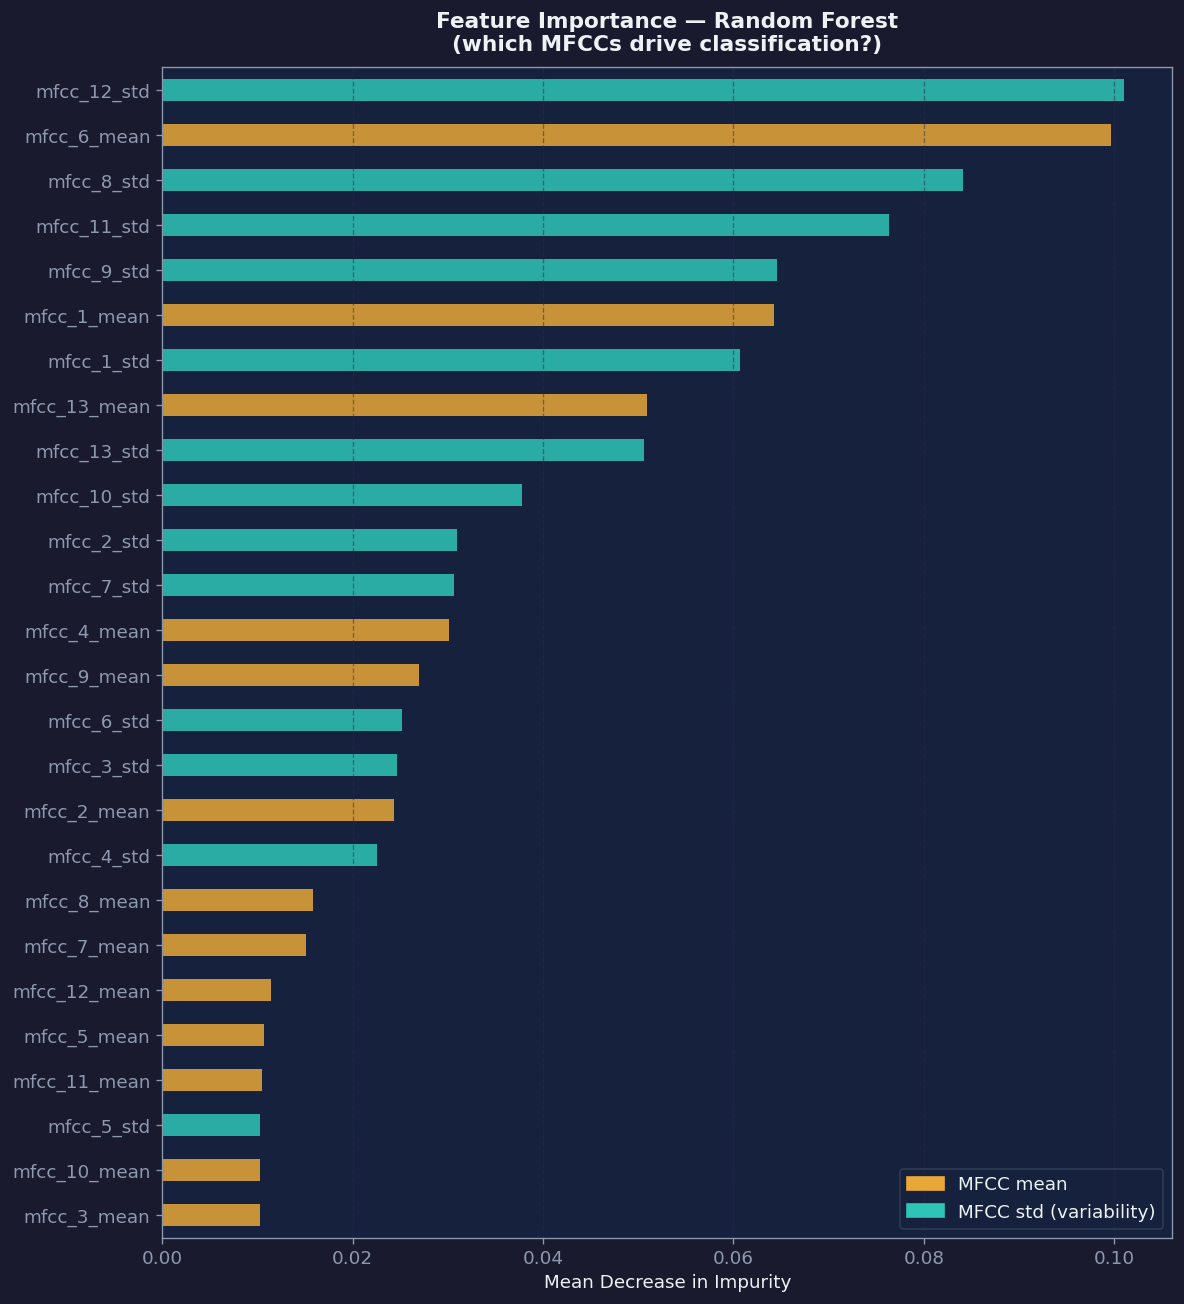

MFCC 1 (overall energy) is typically the single most important feature.
Standard deviation features (variability over time) often carry significant weight —
a steady drone and a rhythmic bark may have similar averages but very different variability.


In [18]:
importances = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=True)

# Colour mean features vs std features differently
colours = [TEAL if '_std' in c else AMBER for c in importances.index]

fig, ax = plt.subplots(figsize=(10, 11))
importances.plot(kind='barh', ax=ax, color=colours, alpha=0.85)
ax.set_title('Feature Importance — Random Forest\n(which MFCCs drive classification?)', pad=10)
ax.set_xlabel('Mean Decrease in Impurity')
ax.grid(True, axis='x')
ax.set_facecolor(PANEL)

# Legend
patches = [
    mpatches.Patch(color=AMBER, label='MFCC mean'),
    mpatches.Patch(color=TEAL,  label='MFCC std (variability)'),
]
ax.legend(handles=patches, framealpha=0.2, edgecolor=MUTED)

plt.tight_layout()
plt.savefig('nb2_fig7_importance.png', bbox_inches='tight', facecolor=BG)
plt.show()
print('MFCC 1 (overall energy) is typically the single most important feature.')
print('Standard deviation features (variability over time) often carry significant weight —')
print('a steady drone and a rhythmic bark may have similar averages but very different variability.')

---
## 10 · Reader Challenge 🎯

You now have a working audio feature extraction and classification pipeline. Here are three ways to extend it:

**Challenge 1 — Richer features**  
Add spectral centroid, spectral rolloff, and zero-crossing rate to the feature vector. These are simple one-liners in librosa. Does accuracy improve?

```python
# Hint:
centroid = librosa.feature.spectral_centroid(y=y, sr=sr).mean()
rolloff  = librosa.feature.spectral_rolloff(y=y, sr=sr).mean()
zcr      = librosa.feature.zero_crossing_rate(y).mean()
```

**Challenge 2 — More MFCCs**  
Re-run the pipeline with `n_mfcc=20` or `n_mfcc=40`. Plot how cross-validation accuracy changes as you increase the number of coefficients. Where does the return diminish?

**Challenge 3 — All folds**  
The full UrbanSound8K evaluation protocol trains on 9 folds and tests on the held-out 10th. Extend the `FOLD1_DIR` logic to loop over all 10 folds and report fold-by-fold accuracy. This is the benchmark used in published papers — how does your random forest compare to the reported baselines?

---
## Summary

| Step | What we did | Key takeaway |
|---|---|---|
| MFCC extraction | 26 numbers per clip | Compresses 22k-number spectrogram to 26 features |
| Class fingerprints | Heatmap of mean MFCCs | Every sound category has a characteristic spectral profile |
| PCA | Linear projection to 2D | Partial separation visible; linear methods have limits |
| t-SNE | Non-linear projection to 2D | Clear cluster structure; confusable pairs identified |
| Random Forest | 5-fold cross-validation | Strong lift above chance; struggling classes match t-SNE overlaps |
| Feature importance | Which MFCCs matter | MFCC 1 dominates; variability features carry substantial weight |

In **next week's project** we move from tabular features to raw spectrograms as model inputs — replacing the manual MFCC pipeline with a convolutional neural network that learns its own features directly from the image.

→ Back to [Notebook 1: Sensory Foundations](NB1_Sensory_Foundations.ipynb)